In [2]:
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd

tickers = ["SPY", "QQQ", "IWM", "EEM"]
#tickers = ["MSFT", "TSLA", "AAPL", "NVDA"]

In [3]:
data= yf.download(tickers, start="2023-1-1", auto_adjust = False, progress=False)
returns = data['Adj Close'].pct_change().dropna()

In [4]:
window = 20 
ma_20 = data['Adj Close'].rolling(window = window).mean()
std_20 = data['Adj Close'].rolling(window = window).std()
z_score = (data['Adj Close'] - ma_20) / std_20


In [5]:
def z_to_signal(z):
    if pd.isna(z):
        return 0
    elif z < -1:
        return 1
    elif z > 1:
        return -1
    else: 
        return 0

signal = z_score.apply(lambda col:col.map(z_to_signal))

In [6]:
cov_window = 60
rolling_var = returns.rolling(cov_window).var()
inv_var = 1/rolling_var
weights = inv_var.div(inv_var.sum(axis=1), axis = 0)

In [7]:
common_index = signal.index.intersection(weights.index)
signal_aligned = signal.loc[common_index]
weights_aligned = weights.loc[common_index]

positions = signal_aligned * weights_aligned
#positions = positions.replace(0, np.nan).ffill()
print(positions.tail())
#positions = positions.replace(0, pd.NA).ffill()


Ticker           EEM       IWM       QQQ       SPY
Date                                              
2026-01-05 -0.239683  0.000000  0.000000  0.000000
2026-01-06 -0.243517 -0.156198  0.000000 -0.399838
2026-01-07 -0.255191 -0.141822  0.000000  0.000000
2026-01-08 -0.273695 -0.138851  0.000000  0.000000
2026-01-09 -0.278962 -0.140541 -0.188243 -0.392254


In [8]:
def cumulative_return(position, ret):
    common_index = position.index.intersection(ret.index)
    pos = position.loc[common_index]
    ret = ret.loc[common_index]
    
    portfolio_value = (ret * pos.shift(1)).sum(axis=1)
    print(portfolio_value.tail())
    cumulative_return = (1 + portfolio_value).cumprod()
    return cumulative_return

Date
2026-01-05   -0.002655
2026-01-06   -0.001770
2026-01-07    0.003483
2026-01-08   -0.001639
2026-01-09   -0.002353
dtype: float64
Date
2026-01-05    0.010376
2026-01-06    0.008844
2026-01-07   -0.003028
2026-01-08    0.001370
2026-01-09    0.007228
dtype: float64


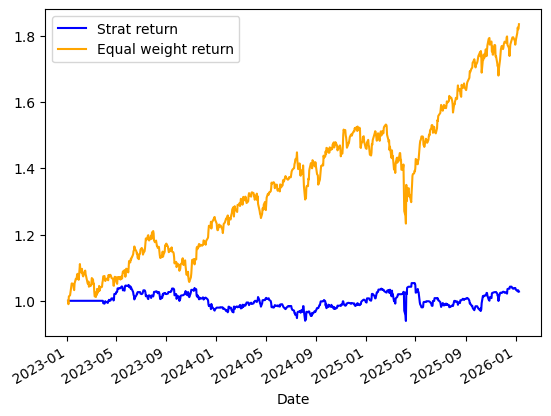

In [9]:
final = cumulative_return(positions, returns)
final.plot(color = 'blue', label = 'Strat return')


benchmark = positions.copy()
benchmark[:] = 0.25
benchmark_chart = cumulative_return(benchmark, returns)
benchmark_chart.plot(color = 'orange', label = 'Equal weight return')
plt.legend()
plt.show()

<Axes: xlabel='Date'>

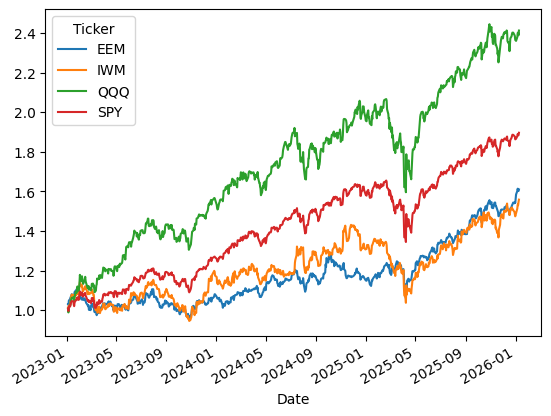

In [10]:
(1 + data['Adj Close'].pct_change()).cumprod().plot()